# Project part 2 - Roei Raz

#

## Imports & Prepare Data Function

#### Input: Receives a raw DataFrame loaded from the CSV file.
#### Data Leakage Prevention: Drops columns that are not available before a movie's release.  
#### Feature Engineering: Adds new feature columns.
#### Output: Cleaned DataFrame with relevant features only 


In [1]:
import pandas as pd  
import numpy as np  
import re
import matplotlib.pyplot as plt  
import seaborn as sns  
import ppscore as pps  
import joblib
import ast
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.pipeline import Pipeline  
from sklearn.impute import SimpleImputer  
from sklearn.preprocessing import StandardScaler, OneHotEncoder  
from sklearn.compose import ColumnTransformer  
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import ElasticNet   
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error  
from sklearn.inspection import permutation_importance

In [2]:
#---------------------------------------------------------------------------------------פעולות----------------------------------------------------------------------
def prepare_data(df):
    
    #עמודת תקציב
    # פעולת ניקוי התא מערכי טקסט
    def clean_budget_advanced(value):
        if pd.isna(value) or str(value).lower() in ['nan', 'unknown', '']: # בדיקה אם הערך חסר
            return 0.0 # החזרת 0 עבור ערכים שלא ניתן לחשב
       
        val_str = str(value).lower() # המרה לטקסט ואותיות קטנות להאחדה
        rates = {'£': 1.3, '€': 1.1, '₹': 0.012, 'rs': 0.012, '¥': 0.007, 'hk$': 0.13, 'a$': 0.65, 'ca$': 0.73, 'sek': 0.09} # שערי מטבע מעודכנים
        multipliers = {'million': 1000000, 'billion': 1000000000, 'crore': 10000000, 'lakh': 100000, 'mio': 1000000} # יחידות מידה
       
        current_rate = 1.0 # ברירת מחדל דולר
        for symbol, rate in rates.items(): # מעבר על מילון המטבעות
            if symbol in val_str: # חיפוש סמל מטבע בטקסט
                current_rate = rate # עדכון שער החליפין
                break
               
        current_multiplier = 1.0 # ברירת מחדל ללא מכפיל
        for word, mult in multipliers.items(): # מעבר על מילון היחידות
            if word in val_str: # חיפוש יחידת מידה בטקסט
                current_multiplier = mult # עדכון המכפיל המתאים
                break
               
        numbers = re.findall(r"[-+]?\d*\.\d+|\d+", val_str.replace(',', '')) # חילוץ המספר הראשון מהטקסט
       
        try:
            if numbers:
                return float(numbers[0]) * current_rate * current_multiplier # חישוב הערך הסופי בדולרים
            return 0.0 # החזרת 0 אם לא נמצא מספר
        except:
            return 0.0 # החזרת 0 במקרה של שגיאת המרה

  
        #ניקוי כל הדאטה פריים מתווים שהם לא אנגלית או מספר
    def clean_non_latin_chars(df, columns):
        df_cleaned = df.copy()
    
        for col in columns:
            if col in df_cleaned.columns:            
                df_cleaned[col] = df_cleaned[col].astype(str).str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
                # הסרת רווחים מיותרים מקצוות הטקסט
                df_cleaned[col] = df_cleaned[col].str.strip()
                # החלפת רצף רווחים ברווח בודד אחד
                df_cleaned[col] = df_cleaned[col].str.replace(r'\s+', ' ', regex=True)
               
        return df_cleaned

    
    
     #טקסט קטן
    def lower(df):
        columns_to_lower = ['primaryTitle', 'genres', 'Language', 'Country', 'plot','directors', 'writers'] # הגדרת רשימת העמודות הרלוונטיות
        for col in columns_to_lower: # מעבר על כל עמודה ברשימה
             if col in df.columns: 
                    df[col] = df[col].astype(str).str.lower()
        return df
   


    #עמודת תקציר החלפה לנאן
    def replace_with_nan(df, column_name, values_to_replace):
        df = df.copy()
        df.loc[df[column_name].isin(values_to_replace), column_name] = np.nan    
        return df 
    


    #עמודת שנת הסרט עד 1900 יחשב כ-נאל
    def start_year(df, column_name):
        df_cleaned = df.copy()
        df_cleaned.loc[df_cleaned[column_name] < 1900, column_name] = np.nan  
        return df_cleaned
    
  


    # עמודת שחקנים המרת השמות לעמודות נפרדות תוך כדי שמירה על הסדר
    def process_actors(val):
        try:
        # אם זה מחרוזת שנראית כמו רשימה, נהפוך אותה לרשימה אמיתית
            if isinstance(val, str):
                val = ast.literal_eval(val)
        
        # אם זה רשימה (או הפך לרשימה), נחתוך 5 ונשלים עם None
            if isinstance(val, list):
                return (val[:5] + [None] * 5)[:5]
        except:
            pass
    
    
        return [None] * 5

# 2. ניקוי עמודות actor_ קודמות כדי להתחיל דף חלק
        cols_to_drop = [c for c in df.columns if c.startswith('actor_') and c != 'lead_actors_ids']
        df = df.drop(columns=cols_to_drop)

# 3. יצירת הנתונים החדשים
        new_data = df['lead_actors_ids'].apply(process_actors).tolist()

        actors_df = pd.DataFrame(new_data, columns=[f'actor_{i+1}' for i in range(5)], index=df.index)
        df = pd.concat([df, actors_df], axis=1)

        return df

    def process_actors(val):
        if pd.isna(val) or val is None:
            return [None] * 5
        try:
            if isinstance(val, str):
                import ast
                val = ast.literal_eval(val.strip())
            if isinstance(val, list):
                return (val[:5] + [None] * 5)[:5]
        except:
            pass
        return [None] * 5
    
    
    #עמודת כותבים חלוקה ל2 עמודות  עם כולב אחד בכל עמודה
    def split_string_column(dataframe, column_name, prefix, max_cols=2):
    
        def process_row(val):
            if pd.isna(val) or val == '':
                return [None] * max_cols
        
        # פיצול לפי פסיק, ניקוי רווחים והסרת ערכים ריקים
            parts = [item.strip() for item in str(val).split(',') if item.strip()]
        
        # חיתוך לפי המקסימום והשלמה ב-None
            return (parts[:max_cols] + [None] * max_cols)[:max_cols]

        cols_to_drop = [c for c in dataframe.columns if c.startswith(f"{prefix}_")]
        dataframe = dataframe.drop(columns=cols_to_drop, errors='ignore')

    # 2. יצירת רשימת הנתונים המעובדים
        new_data = dataframe[column_name].apply(process_row).tolist()
    
    # 3. יצירת שמות העמודות (writer_1, writer_2...)
        new_cols_names = [f"{prefix}_{i+1}" for i in range(max_cols)]
    
    # 
        expanded_df = pd.DataFrame(new_data, columns=new_cols_names, index=dataframe.index)
    
        return pd.concat([dataframe, expanded_df], axis=1)
    
    
    #עמודת סוגות- סוגה בכל עמודה
    def clean_genres_column(df):
   
        # 1. ניקוי הסוגריים והגרשיים
        df['genres'] = df['genres'].str.replace(r"[\[\]\"']", '', regex=True)
        split_genres = df['genres'].str.split(',', n=3, expand=True)
        max_columns = min(split_genres.shape[1], 3)
    
        for i in range(max_columns):
            df[f'genre_{i+1}'] = split_genres[i].str.strip()
        
        df = df.drop(columns=['genres']) 
    
        return df
    
    
    #ניקוי תווים בלתי נראים
    def clean_text_for_ml(df):
    
        
        df = df.copy()
    
        # איתור אוטומטי של כל העמודות שהן מסוג טקסט (object או string)
        text_cols = df.select_dtypes(include=['object', 'string']).columns
    
        for col in text_cols:
            df[col] = df[col].fillna('').astype(str)
            df[col] = df[col].str.replace(r'[\x00-\x1F\x7F-\x9F\u200b-\u200d\ufeff]', '', regex=True)
            df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
            df[col] = df[col].str.strip()
            df[col] = df[col].str.lower()
        
        return df
    
    
    
        #ערכי נאל זהיים
    def standardize_missing_values(df):
        df = df.copy()  
        for col in df.select_dtypes(
            include=["object", "string"]
        ).columns:  
            df[col] = (
                df[col]
                .astype(str)  
                .str.replace(
                    r"\n", " ", regex=True
                )  
                .str.replace(
                    r"\\n", " ", regex=True
                )  
                .str.replace(
                    r"\\", " ", regex=True
                )  
                .str.strip() 
            )

    
        missing_variants = [
        "n/",
        "nan",
        "Nan",
        "NAN",
        "none",
        "None",
        "null",
        "Null",
        "NULL",
        "",  
        " ",  
        "N/A",
        "n/a",
        "NA",
        "na",
        "-",
        ]

        
        df = df.replace(
        missing_variants, np.nan
        )  

        return df  
    

    
    
        ##------------------------------------------------------------------------------my features-----------------------------------------------------------------------
    
    
    #f1 - actors * ganars
    def add_my_custom_features(df):
       
        df = df.copy()      
        actor_cols = [
            c for c in df.columns if c.startswith("actor_")
        ]  
        genre_cols = [
            c for c in df.columns if c.startswith("genre_")
        ]  
        writer_cols = [
            c for c in df.columns if c.startswith("writer_")
        ]  

            # פונקציית עזר פנימית שמנקה טקסט ובודקת אם התא מייצג ערך חסר
        def is_missing(val):
            val_str = (
                str(val).lower().strip()
            )  
            return val_str in [
                "nan",
                "none",
                "null",
                "",
                "n/a",
                "-",
            ]  # החזרת True אם הטקסט מייצג ערך חסר, אחרת False

        
        df["actor_count"] = (
            df[actor_cols].map(is_missing).eq(False).sum(axis=1)
        )  # ספירת תאים שאינם חסרים בעמודות השחקנים
        df["genre_count"] = (
            df[genre_cols].map(is_missing).eq(False).sum(axis=1)
        ) 

          #חישוב בפועל
        df["my_features_1_ActorGenerInteraction"] = (
            df["actor_count"] * df["genre_count"]
        )

    # -------------------------------------------------------------------------
    #   F2 פיצ'ר בינארי לטווח אורך סרט אופטימלי (120 עד 140 דקות) 
        df["my_features_2_runtime_range"] = (
            df["runtimeMinutes"].between(120, 140).astype(int)
        )

    # -------------------------------------------------------------------------
    # F3- תקציב ושנת יציאה בינארי 
        df["myfeatures_3_year_budget"] = (
            (df["budget"] > 5000000) & (df["startYear"] > 1970)
        ).astype(int)

    # -------------------------------------------------------------------------
    # F4 - יחס זמן ריצה ופיצר 1
        df["myfeatures_4_runtime_feat1"] = np.where(
            df["my_features_1_ActorGenerInteraction"] == 0, 
            0, 
            df["runtimeMinutes"] / df["my_features_1_ActorGenerInteraction"]
        ) 
    # -------------------------------------------------------------------------
    #F5
    # בדיקה באמצעות פונקציית העזר האם שני התאים מוגדרים כחסרים בו-זמנית
        df["my_features_5_no_leader_missing"] = (
            df["writer_1"].map(is_missing) & df["actor_1"].map(is_missing)
        ).astype(int)

    # -------------------------------------------------------------------------
   
        df = df.drop(
            ["actor_count", "genre_count"], axis=1, errors="ignore"
        ) 

        return df 
    
    
    
    
    
    #---------------------------------------------------------------------------------------קוד הפעלת הפעולות----------------------------------------------------------------------
    
    #------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
   


    #הוספת עמודות שלא קיימות בדאטה שקיבלנו
    df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors', 'writers'])
    


    df = pd.merge(df, df_crew, on='tconst', how='left') # חיבור נתוני צוות לטבלה המלאה על בסיס מפתח משותף
    
    
    #  הסרת עמודות שאינן ידועות לפני יציאת הסרט
    df = df.drop(['numVotes', 'BoxOffice'], axis=1, errors='ignore') 
    df = df.drop_duplicates()
   
    #תקציב
    df['budget'] = df['budget'].apply(clean_budget_advanced) #
    
    
    # ניקוי עמודות טקטס
    columns_to_fix = ['tconst', 'primaryTitle' ,'Language', 'Country' ,'plot']
    df = clean_non_latin_chars(df, columns_to_fix) # הרצת הניקוי על הדאטה
 
    #אותיות קטנות
    df = lower(df)
   
    # עמודת תקציר החלפץ ערכים לnan
    text = ["no plot found" , "plot description missing"]
    df= replace_with_nan(df, 'plot', text)
    
    
    #עמודת שנת התחלה גדולה מ1900
    df = start_year(df, 'startYear')
        
    
   
    # שחקנים
    cols_to_drop = [c for c in df.columns if c.startswith('actor_') and c != 'lead_actors_ids']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    new_data = df['lead_actors_ids'].apply(process_actors).tolist()
    actors_df = pd.DataFrame(new_data, columns=[f'actor_{i+1}' for i in range(5)], index=df.index)
    df = pd.concat([df, actors_df], axis=1)
    df = df.drop(['lead_actors_ids'] , axis=1, errors='ignore')
    
    

    #כותבים
    df = split_string_column(df, 'writers', prefix='writer', max_cols=2)
    df = df.drop(['writers'] , axis=1, errors='ignore')
    
    
    # --- במאים ---
    df['directors'] = df['directors'].str.split(',').str[0].str.strip()
      

    # --- הרצה ג'אנרים---
    df = clean_genres_column(df)

    #תווים בלתי נראים
    df = clean_text_for_ml(df)
      
    #nulls
    df = standardize_missing_values(df)
       
    #my features
    df = add_my_custom_features(df)
    
    
    return df 

In [3]:
#קריאה לנתנונים מקובץ CSV והפעלת פעולת PREPARE DATA עליה
df = pd.read_csv('dataset.csv', dtype={'budget': str})
df = prepare_data(df)

## Separating test and train data

In [4]:
def Boruta_filter(df):
    selected_boruta_features = [
        'startYear', 'runtimeMinutes', 'budget', 'Language', 'Country',
        'actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 
        'writer_1', 'writer_2', 'genre_1', 'genre_2', 'genre_3', 
        'my_features_1_ActorGenerInteraction', 'my_features_2_runtime_range', 
        'myfeatures_4_runtime_feat1', 'myfeatures_3_year_budget', 
        'my_features_5_no_leader_missing' 
    ]  
   
    df_processed = df.copy() 
    return df_processed[selected_boruta_features]
 

df = df.dropna(subset=['averageRating']) 
X = Boruta_filter(df) 
y = df['averageRating'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Pipeline creation

#### Data Model Training: Elastic Net & Random Forest
#### Imputation , Standardization and Encoding
#### 10-Fold Cross-Validation 

In [5]:
# מיון אוטומטי של הפיצ'רים הנבחרים לפי טיפוסים מתוך הנתונים המעובדים
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist() 
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist() 

if 'startYear' in numeric_features: # בדיקה האם שנת ההתחלה נמצאת בתוך הרשימה הנומרית הכללית
    numeric_features.remove('startYear') # הוצאת שנת ההתחלה מרשימת הנומריים הרגילה לצורך טיפול ייחודי

# יצירת צינורות
year_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='mean')), # השלמת ערכים חסרים באמצעות ממוצע השנים
    ('scaler', StandardScaler()) # נרמול ערכי השנה לממוצע 0 וסטיית תקן 1
]) 

numeric_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='median')), # השלמת ערכים חסרים באמצעות חציון למניעת רגישות לחריגים קיצוניים
    ('scaler', StandardScaler()) 
]) 
   
categorical_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=True))
]) 

# פרוססור שמאחד את כל הצינורות למודל אחרי שכל אחד טופל אחרת
preprocessor = ColumnTransformer( 
    transformers=[ 
        ('year_num', year_transformer, ['startYear']), 
        ('cat_cols', categorical_transformer, categorical_features), 
        ('num_cols', numeric_transformer, numeric_features)
    ], 
    remainder='drop' 
)


# הרצת המודלים 
elastic_net_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.1, random_state=42)) 
]) 

# Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', RandomForestRegressor(n_estimators=100, max_leaf_nodes=25, min_samples_leaf=15, random_state=42)) 
])


# CV & הדפסה
def run_10_fold_cv(pipeline, X, y, model_name="Model"):
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42) #  חלוקה ל-10 פולדס רנדומליים 
   
    scoring_metrics = { 
        'r2': 'r2', 
        'mae': 'neg_mean_absolute_error', 
        'mse': 'neg_mean_squared_error' 
    } 
   
    cv_results = cross_validate(pipeline, X, y, cv=cv_strategy, scoring=scoring_metrics, n_jobs=-1, return_estimator=True) # הוספנו return_estimator=True כדי לחלץ את מספר הפיצ'רים המדויק
   
    r2_scores = cv_results['test_r2'] 
    mae_scores = -cv_results['test_mae'] # חילוץ והפיכת מדדי ה-MAE לחיוביים
    rmse_scores = np.sqrt(-cv_results['test_mse']) 
   
    n = len(y)
   
    first_estimator = cv_results['estimator'][0]
    if hasattr(first_estimator.named_steps['preprocessor'], 'get_feature_names_out'):
        p = len(first_estimator.named_steps['preprocessor'].get_feature_names_out())
    else:
        p = X.shape[1]
       
    r2_adj_scores = 1 - ((1 - r2_scores) * (n - 1) / (n - p - 1))
   
    print(f"\n========== {model_name} (10-Fold CV Results) ==========") # כותרת המודל
    print(f"R² Score:    Mean = {np.mean(r2_scores):.4f} | Std = {np.std(r2_scores):.4f}") # הדפסת ממוצע וסטיית תקן של R²
    print(f"Adj R² Score: Mean = {np.mean(r2_adj_scores):.4f} | Std = {np.std(r2_adj_scores):.4f}") # הדפסת ממוצע וסטיית תקן של Adjusted R²
    print(f"MAE Score:    Mean = {np.mean(mae_scores):.4f} | Std = {np.std(mae_scores):.4f}") # הדפסת ממוצע וסטיית תקן של MAE
    print(f"RMSE Score:   Mean = {np.mean(rmse_scores):.4f} | Std = {np.std(rmse_scores):.4f}") # הדפסת ממוצע וסטיית תקן של RMSE
    print("-" * 55) 


run_10_fold_cv(elastic_net_pipeline, X_train, y_train, model_name="Elastic Net") 
run_10_fold_cv(rf_pipeline, X_train, y_train, model_name="Random Forest")

elastic_net_pipeline.fit(X_train, y_train) 
rf_pipeline.fit(X_train, y_train)


========== Elastic Net (10-Fold CV Results) ==========
R² Score:    Mean = 0.2511 | Std = 0.0069
Adj R² Score: Mean = 0.2481 | Std = 0.0070
MAE Score:    Mean = 0.8551 | Std = 0.0076
RMSE Score:   Mean = 1.1200 | Std = 0.0128
-------------------------------------------------------

========== Random Forest (10-Fold CV Results) ==========
R² Score:    Mean = 0.2320 | Std = 0.0054
Adj R² Score: Mean = 0.2288 | Std = 0.0054
MAE Score:    Mean = 0.8702 | Std = 0.0068
RMSE Score:   Mean = 1.1342 | Std = 0.0120
-------------------------------------------------------


C:\Users\PC\anaconda3\envs\my_new_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.925e+03, tolerance: 1.549e+01
  model = cd_fast.sparse_enet_coordinate_descent(


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('year_num', ...), ('cat_cols', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Error Analysis

#### 20 worst predictions of the better model (Elastic Net). 
#### Sorted by max eror

In [6]:
y_pred = elastic_net_pipeline.predict(X_test)
error_analysis_df = pd.DataFrame(index=X_test.index)


if 'primaryTitle' in df.columns:
    error_analysis_df['primaryTitle'] = df.loc[X_test.index, 'primaryTitle']
elif 'title' in df.columns:
    error_analysis_df['primaryTitle'] = df.loc[X_test.index, 'title']
else:
    error_analysis_df['primaryTitle'] = "Title Column Missing"

# הוספת הערכים האמיתיים, המנובאים וחישוב הטעות
error_analysis_df['Actual_Rating'] = y_test
error_analysis_df['Predicted_Rating'] = y_pred
error_analysis_df['Error'] = error_analysis_df['Predicted_Rating'] - error_analysis_df['Actual_Rating']



top_10_overpredictions = error_analysis_df.sort_values(by='Error', ascending=False).head(10)


top_10_underpredictions = error_analysis_df.sort_values(by='Error', ascending=True).head(10)

combined_df = pd.concat([
    top_10_overpredictions.assign(Type='Overprediction'), 
    top_10_underpredictions.assign(Type='Underprediction')
])

sorted_combined_df = combined_df.sort_values(
    by='Error', 
    key=lambda x: x.abs(), 
    ascending=False
)

combined_df

,primaryTitle,Actual_Rating,Predicted_Rating,Error,Type
52582,rape of the soul,1.7,7.999982,6.299982,Overprediction
84069,zwischen glck und krone,1.2,7.400849,6.200849,Overprediction
12464,justin bieber always believing,1.0,7.140435,6.140435,Overprediction
133563,horseplay the history of horse riding,1.0,6.911696,5.911696,Overprediction
52638,ramo trip,1.4,7.202234,5.802234,Overprediction
10554,jasenovac istina,1.4,6.814732,5.414732,Overprediction
6032,idaho,1.9,7.101870,5.201870,Overprediction
75856,torchbearer,2.4,7.542660,5.142660,Overprediction
47899,pure hearts into chinese showbiz,1.0,5.942280,4.942280,Overprediction
55253,sewol paused in time,2.0,6.929050,4.929050,Overprediction


## 20 outliers of both models
#### sorted by max error

In [7]:
def get_display_columns(dataframe):
    base_cols = ['startYear', 'Actual_Rating', 'Predicted_Rating', 'Absolute_Error']
    for col in ['primaryTitle', 'movie_name', 'title']:
        if col in dataframe.columns:
            base_cols.insert(0, col)
            break
    return base_cols

# 
# -  Elastic Net

y_pred_en = elastic_net_pipeline.predict(X_test)
y_pred = rf_pipeline.predict(X_test)

worst_en_df = df.loc[X_test.index].copy()
worst_en_df['Predicted_Rating'] = y_pred_en
worst_en_df['Actual_Rating'] = y_test
worst_en_df['Absolute_Error'] = (worst_en_df['Actual_Rating'] - worst_en_df['Predicted_Rating']).abs()

# מיון מהשגיאה הגבוהה ביותר לנמוכה  ושליפת 20 הראשונים
top_20_worst_en = worst_en_df.sort_values(by='Absolute_Error', ascending=False).head(20)




# RF

worst_rf_df = df.loc[X_test.index].copy()
worst_rf_df['Predicted_Rating'] = y_pred
worst_rf_df['Actual_Rating'] = y_test
worst_rf_df['Absolute_Error'] = (worst_rf_df['Actual_Rating'] - worst_rf_df['Predicted_Rating']).abs()

# מיון מהשגיאה הגבוהה ביותר לנמוכה ושליפת 20 הראשונים
top_20_worst_rf = worst_rf_df.sort_values(by='Absolute_Error', ascending=False).head(20)





#איחוד
combined_df = pd.concat([
    top_20_worst_en.assign(Model_Type='Elastic Net'), 
    top_20_worst_rf.assign(Model_Type='RF')
])

# 2. מיון כל 40 השורות (20 מכל מודל) לפי השגיאה המוחלטת מהגבוה לנמוך
sorted_combined_df = combined_df.sort_values(
    by='Absolute_Error', 
    ascending=False
)

columns_to_show = ['primaryTitle', 'Actual_Rating', 'Predicted_Rating', 'Absolute_Error', 'Model_Type']

sorted_combined_df[columns_to_show]

,primaryTitle,Actual_Rating,Predicted_Rating,Absolute_Error,Model_Type
52582,rape of the soul,1.7,7.999982,6.299982,Elastic Net
84069,zwischen glck und krone,1.2,7.400849,6.200849,Elastic Net
12464,justin bieber always believing,1.0,7.153158,6.153158,RF
12464,justin bieber always believing,1.0,7.140435,6.140435,Elastic Net
133563,horseplay the history of horse riding,1.0,7.122595,6.122595,RF
84069,zwischen glck und krone,1.2,7.125885,5.925885,RF
133563,horseplay the history of horse riding,1.0,6.911696,5.911696,Elastic Net
52638,ramo trip,1.4,7.202234,5.802234,Elastic Net
52638,ramo trip,1.4,7.153158,5.753158,RF
10554,jasenovac istina,1.4,7.153158,5.753158,RF


## Fairness Analysis
#### geners & start year

In [8]:

# הגדרת עיצוב בסיסי לגרפים
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'  # תמיכה בסיסית בפונטים


y_pred_en = elastic_net_pipeline.predict(X_test)
y_pred = rf_pipeline.predict(X_test)

analysis_df = X_test.copy()
analysis_df['actual'] = y_test
analysis_df['pred_elastic_net'] = y_pred_en
analysis_df['pred_rf'] = y_pred
analysis_df['decade'] = (analysis_df['startYear'] // 10) * 10

# 
results_data = []

def collect_metrics(df_sub, segment_type, segment_name):
    if len(df_sub) == 0:
        return
    
    # חישוב עבור Elastic Net
    mae_en = mean_absolute_error(df_sub['actual'], df_sub['pred_elastic_net'])
    rmse_en = np.sqrt(mean_squared_error(df_sub['actual'], df_sub['pred_elastic_net']))
    
    # חישוב עבור rf
    mae_rf = mean_absolute_error(df_sub['actual'], df_sub['pred_rf'])
    rmse_rf = np.sqrt(mean_squared_error(df_sub['actual'], df_sub['pred_rf']))
    
   
    results_data.append({'Segment_Type': segment_type, 'Group': segment_name, 'Model': 'Elastic Net', 'Metric': 'MAE', 'Value': mae_en})
    results_data.append({'Segment_Type': segment_type, 'Group': segment_name, 'Model': 'Elastic Net', 'Metric': 'RMSE', 'Value': rmse_en})
    results_data.append({'Segment_Type': segment_type, 'Group': segment_name, 'Model': 'Random Forest', 'Metric': 'MAE', 'Value': mae_rf})
    results_data.append({'Segment_Type': segment_type, 'Group': segment_name, 'Model': 'Random Forest', 'Metric': 'RMSE', 'Value': rmse_rf})


# א) ז'אנרים
genre_cols = ['genre_1', 'genre_2', 'genre_3']
all_genres = analysis_df[genre_cols].stack()
top_5_genres = all_genres.value_counts().head(5).index.tolist()

for genre in top_5_genres:
    genre_mask = analysis_df[genre_cols].isin([genre]).any(axis=1)
    collect_metrics(analysis_df[genre_mask], 'Genre', genre)

# ב) עשורים
decades = sorted(analysis_df[analysis_df['decade'] >= 1950]['decade'].dropna().unique())
for decade in decades:
    decade_mask = analysis_df['decade'] == decade
    collect_metrics(analysis_df[decade_mask], 'Decade', f"{int(decade)}s")

# 
df_results = pd.DataFrame(results_data)

# שלב 3: הצגת התוצאות בטבלאות סיכום ()
print("\n" + "="*60)
print(" טבלת ביצועים לפי חמשת הז'אנרים המובילים")
print("="*60)
df_genre_pivot = df_results[df_results['Segment_Type'] == 'Genre'].pivot(index='Group', columns=['Model', 'Metric'], values='Value')
# סדר עמודות הגיוני
df_genre_pivot = df_genre_pivot.reindex(columns=['MAE', 'RMSE'], level=1)
print(df_genre_pivot.round(4).to_string())

print("\n" + "="*60)
print(" טבלת ביצועים לפי עשור יציאה (החל מ-1950)")
print("="*60)
df_decade_pivot = df_results[df_results['Segment_Type'] == 'Decade'].pivot(index='Group', columns=['Model', 'Metric'], values='Value')
df_decade_pivot = df_decade_pivot.reindex(columns=['MAE', 'RMSE'], level=1)
print(df_decade_pivot.round(4).to_string())



 טבלת ביצועים לפי חמשת הז'אנרים המובילים
Model       Elastic Net         Random Forest        
Metric              MAE    RMSE           MAE    RMSE
Group                                                
action           0.9730  1.2398        0.9775  1.2617
comedy           0.8693  1.1236        0.8753  1.1337
documentary      0.7499  1.0325        0.7443  1.0249
drama            0.8085  1.0528        0.8218  1.0650
romance          0.7788  1.0108        0.7800  1.0149

 טבלת ביצועים לפי עשור יציאה (החל מ-1950)
Model  Elastic Net         Random Forest        
Metric         MAE    RMSE           MAE    RMSE
Group                                           
1950s       0.6837  0.8943        0.7046  0.9201
1960s       0.7850  0.9733        0.8076  0.9988
1970s       0.8133  1.0234        0.8219  1.0376
1980s       0.8151  1.0391        0.8240  1.0461
1990s       0.8280  1.0475        0.8412  1.0618
2000s       0.8853  1.1540        0.8887  1.1573
2010s       0.9051  1.1858        0.9147  

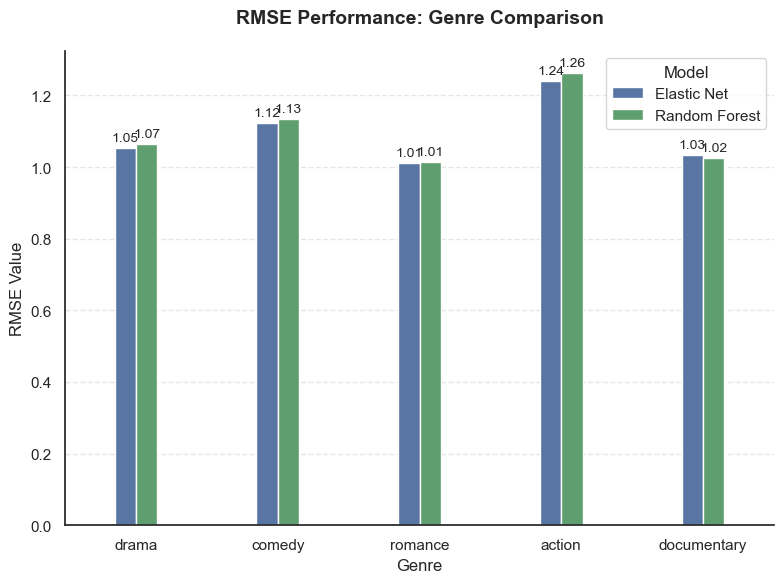

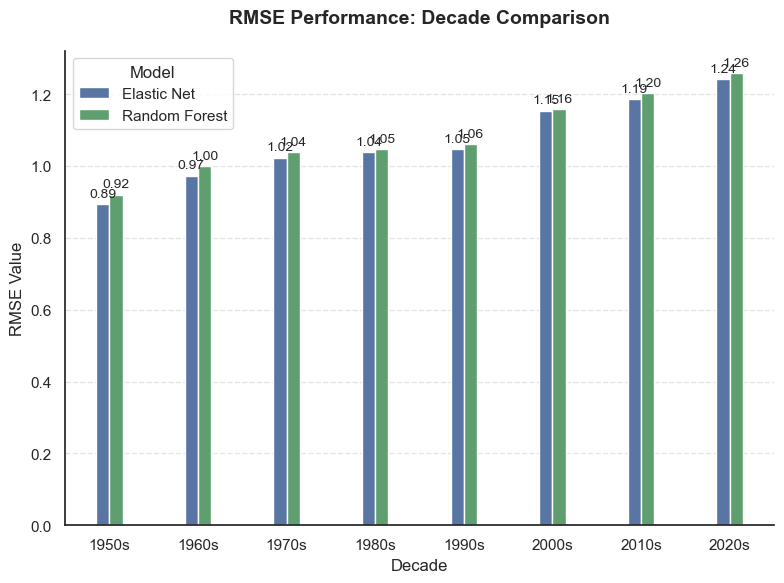

In [9]:
def plot_modern_rmse(df_all, segment_name, title):
    
    df_sub = df_all[(df_all['Segment_Type'] == segment_name) & (df_all['Metric'] == 'RMSE')].copy()
    
   
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    
    bar_plot = sns.barplot(
        data=df_sub,
        x='Group', y='Value', hue='Model',
        palette=['#4c72b0', '#55a868'],
        width=0.3, # עמודות דקות
        ax=ax
    )
    
    # הוספת כותרות ועיצוב צירים
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('RMSE Value', fontsize=12)
    ax.set_xlabel(segment_name, fontsize=12)
    sns.despine(right=True) 
    ax.grid(axis='y', linestyle='--', alpha=0.5) 
    
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
        
    plt.tight_layout()
    plt.show()

# הרצה עבור ז'אנרים ועשורים
plot_modern_rmse(df_results, 'Genre', 'RMSE Performance: Genre Comparison')
plot_modern_rmse(df_results, 'Decade', 'RMSE Performance: Decade Comparison')

## Feature importance

In [10]:
#לקיחת הפרוססור שכבר  רץ בעבר על האלסטיק
fitted_preprocessor = elastic_net_pipeline.named_steps['preprocessor']
feature_names = fitted_preprocessor.get_feature_names_out()

en_model = elastic_net_pipeline.named_steps['model']
en_coefs = en_model.coef_

# יצירת טבלה למציאת 5 הגדולים
en_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': en_coefs})
en_df['Abs_Coef'] = np.abs(en_df['Coefficient'])
en_top_5 = en_df.sort_values(by='Abs_Coef', ascending=False).head(5)
en_top_5['Direction'] = en_top_5['Coefficient'].apply(lambda x: 'חיובי (+)' if x > 0 else 'שלילי (-)')
en_top_5

,Feature,Coefficient,Abs_Coef,Direction
409,cat_cols__genre_1_documentary,1.246843,1.246843,חיובי (+)
430,cat_cols__genre_2_documentary,1.085237,1.085237,חיובי (+)
414,cat_cols__genre_1_horror,-1.021795,1.021795,שלילי (-)
452,cat_cols__genre_3_documentary,0.789522,0.789522,חיובי (+)
436,cat_cols__genre_2_horror,-0.774105,0.774105,שלילי (-)


In [11]:
# 1. חילוץ המודל והפיצ'רים מה-Pipeline שכבר אומן
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']
feature_names = fitted_preprocessor.get_feature_names_out()

rf_model = rf_pipeline.named_steps['model']
rf_importances = rf_model.feature_importances_

# 2. יצירת טבלה למציאת 5 הגדולים
rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
rf_top_5 = rf_df.sort_values(by='Importance', ascending=False).head(5)

# 3. הצגת התוצאות
print("5 הפיצ'רים המשפיעים ביותר במודל ה-Random Forest:")
rf_top_5

5 הפיצ'רים המשפיעים ביותר במודל ה-Random Forest:


,Feature,Importance
409,cat_cols__genre_1_documentary,0.307153
414,cat_cols__genre_1_horror,0.200377
494,num_cols__runtimeMinutes,0.163302
430,cat_cols__genre_2_documentary,0.073640
0,year_num__startYear,0.060778


# THE END.